In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [3]:
url = 'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv'

In [4]:
!wget -O sms_spam.csv {url}

--2026-02-18 11:37:26--  https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 477907 (467K) [text/plain]
Saving to: ‘sms_spam.csv’

sms_spam.csv        100%[===================>] 466.71K  --.-KB/s    in 0.006s  

2026-02-18 11:37:26 (77.4 MB/s) - ‘sms_spam.csv’ saved [477907/477907]



In [5]:
df = pd.read_csv('sms_spam.csv', sep='\t', header=None, names=['label', 'message'])

print(f"Dataset shape: {df.shape}")
print(df.head())


Dataset shape: (5572, 2)
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [6]:
print("Dataset Info:")
print(df.info())

print("\n Class Distribution:")
print(df['label'].value_counts())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

 Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


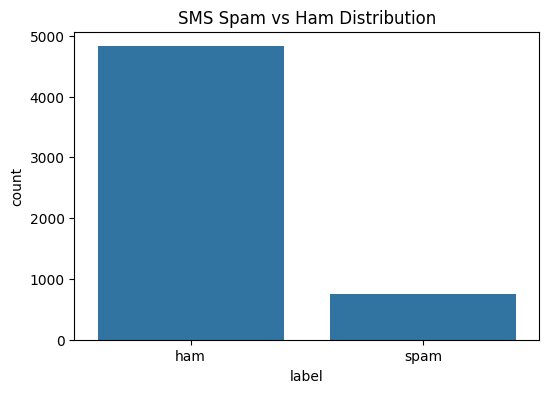

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label')
plt.title('SMS Spam vs Ham Distribution')
plt.show()

In [8]:
df['message_length'] = df['message'].apply(len)

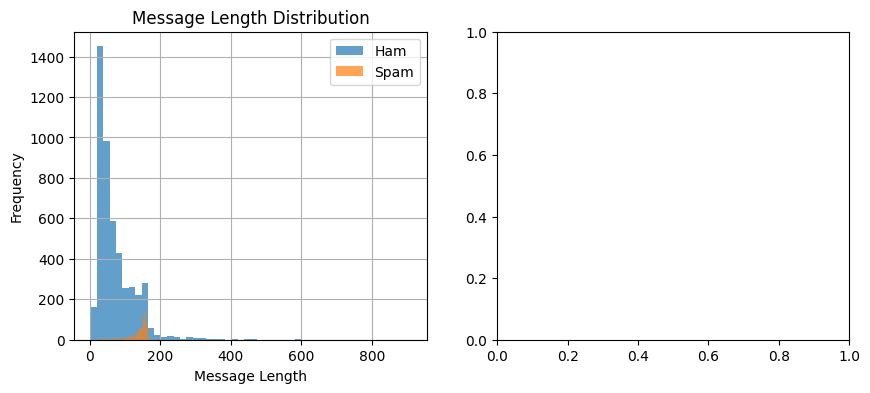

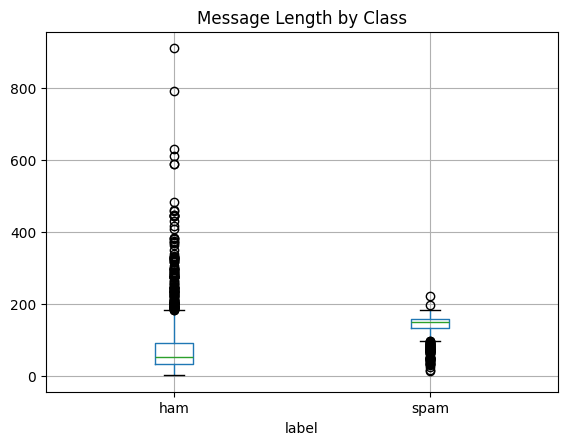


 Message Length Stats:
        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4825.0   71.482487  58.440652   2.0   33.0   52.0   93.0  910.0
spam    747.0  138.670683  28.873603  13.0  133.0  149.0  157.0  223.0


In [9]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df[df['label']=='ham']['message_length'].hist(bins=50, alpha=0.7, label='Ham')
df[df['label']=='spam']['message_length'].hist(bins=50, alpha=0.7, label='Spam')
plt.legend()
plt.xlabel('Message Length')
plt.ylabel('Frequency')
plt.title('Message Length Distribution')

plt.subplot(1, 2, 2)
df.boxplot(column='message_length', by='label')
plt.title('Message Length by Class')
plt.suptitle('')
plt.show()

print(f"\n Message Length Stats:")
print(df.groupby('label')['message_length'].describe())

In [10]:
X = df['message']  # Features (text messages)
y = df['label']    # Target (spam or ham)

In [12]:
y_binary = y.map({'spam': 1, 'ham': 0})

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nClass distribution:")
print(y.value_counts())

Features shape: (5572,)
Target shape: (5572,)

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary  # Maintain class distribution
)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTesting set class distribution:")
print(y_test.value_counts())

Training set size: 4457
Testing set size: 1115

Training set class distribution:
label
0    3859
1     598
Name: count, dtype: int64

Testing set class distribution:
label
0    966
1    149
Name: count, dtype: int64


In [14]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f" TF-IDF Vectorization complete!")
print(f"Training features shape: {X_train_tfidf.shape}")
print(f"Testing features shape: {X_test_tfidf.shape}")
print(f"Number of features: {len(tfidf_vectorizer.get_feature_names_out())}")

 TF-IDF Vectorization complete!
Training features shape: (4457, 5000)
Testing features shape: (1115, 5000)
Number of features: 5000


In [15]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [16]:
y_pred = nb_model.predict(X_test_tfidf)

 Model Accuracy: 0.9740 (97.40%)

 Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.99       966
        Spam       1.00      0.81      0.89       149

    accuracy                           0.97      1115
   macro avg       0.99      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



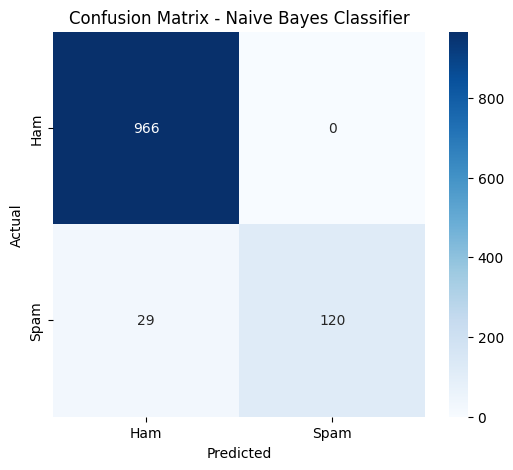

In [17]:
accuracy = accuracy_score(y_test, y_pred)
print(f" Model Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Naive Bayes Classifier')
plt.show()

Multinomial NB Accuracy: 0.9740
Bernoulli NB Accuracy: 0.9704
Gaussian NB Accuracy: 0.8583


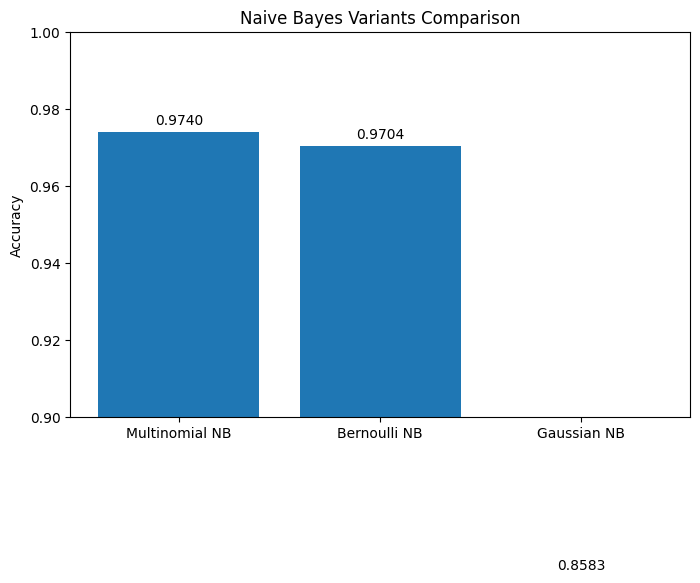

In [18]:
models = {
    'Multinomial NB': MultinomialNB(),
    'Bernoulli NB': BernoulliNB(),
    'Gaussian NB': GaussianNB()
}

results = {}

for name, model in models.items():
    if name == 'Gaussian NB':
        model.fit(X_train_tfidf.toarray(), y_train)
        y_pred = model.predict(X_test_tfidf.toarray())
    else:
        model.fit(X_train_tfidf, y_train)
        y_pred = model.predict(X_test_tfidf)

    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.4f}")

plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values())
plt.ylabel('Accuracy')
plt.title('Naive Bayes Variants Comparison')
plt.ylim(0.9, 1.0)
for i, (name, acc) in enumerate(results.items()):
    plt.text(i, acc + 0.002, f'{acc:.4f}', ha='center')
plt.show()

In [19]:
def predict_spam(message):
    """Function to predict if a message is spam or ham"""
    message_tfidf = tfidf_vectorizer.transform([message])

    prediction = nb_model.predict(message_tfidf)[0]
    probability = nb_model.predict_proba(message_tfidf)[0]

    result = "SPAM" if prediction == 1 else "HAM"
    confidence = max(probability) * 100

    return result, confidence


test_messages = [
    "Congratulations! You've won a free iPhone. Click here to claim your prize now!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your account has been compromised. Verify immediately: http://fake-link.com",
    "Don't forget to buy milk on your way home",
    "You have been selected for a $1000 gift card. Call now!"
]

print("🔍 Testing Custom Messages:")
print("-" * 60)
for msg in test_messages:
    result, confidence = predict_spam(msg)
    print(f"Message: {msg[:50]}...")
    print(f"Prediction: {result} (Confidence: {confidence:.2f}%)")
    print("-" * 60)

🔍 Testing Custom Messages:
------------------------------------------------------------
Message: Congratulations! You've won a free iPhone. Click h...
Prediction: SPAM (Confidence: 86.81%)
------------------------------------------------------------
Message: Hey, are we still meeting for lunch tomorrow?...
Prediction: HAM (Confidence: 99.73%)
------------------------------------------------------------
Message: URGENT: Your account has been compromised. Verify ...
Prediction: SPAM (Confidence: 83.86%)
------------------------------------------------------------
Message: Don't forget to buy milk on your way home...
Prediction: HAM (Confidence: 99.18%)
------------------------------------------------------------
Message: You have been selected for a $1000 gift card. Call...
Prediction: SPAM (Confidence: 60.48%)
------------------------------------------------------------


In [20]:
feature_names = tfidf_vectorizer.get_feature_names_out()

In [21]:
spam_log_probs = nb_model.feature_log_prob_[1]

In [22]:
top_n = 20
top_indices = np.argsort(spam_log_probs)[-top_n:]

print(f"🔝 Top {top_n} words associated with SPAM:")
print("-" * 40)
for idx in reversed(top_indices):
    print(f"{feature_names[idx]}: {np.exp(spam_log_probs[idx]):.4f}")

🔝 Top 20 words associated with SPAM:
----------------------------------------
free: 0.0034
txt: 0.0025
stop: 0.0022
claim: 0.0021
text: 0.0021
mobile: 0.0020
reply: 0.0019
ur: 0.0019
www: 0.0018
prize: 0.0017
uk: 0.0017
service: 0.0015
new: 0.0015
cash: 0.0015
won: 0.0015
150p: 0.0014
urgent: 0.0014
com: 0.0013
win: 0.0013
50: 0.0012


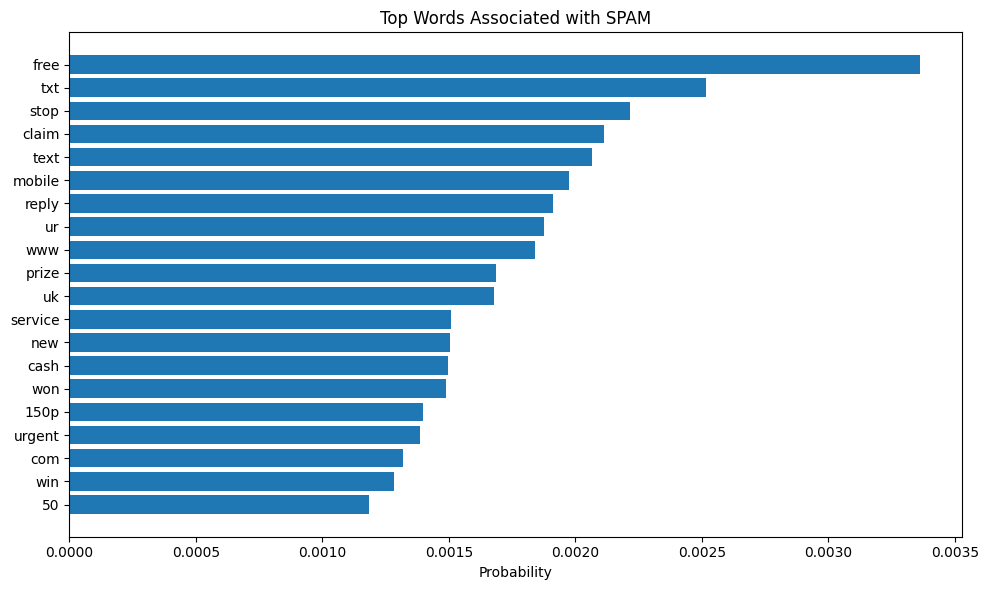

In [23]:
plt.figure(figsize=(10, 6))
top_words = [feature_names[i] for i in top_indices]
top_scores = [np.exp(spam_log_probs[i]) for i in top_indices]

plt.barh(top_words, top_scores)
plt.xlabel('Probability')
plt.title('Top Words Associated with SPAM')
plt.tight_layout()
plt.show()